# PART 1: DATA CLEANING

I would keep the below 20 variables because it includes useful variables like address, amenities, the house size , their bedrroms numbers and the conditions of the houses which are important in predicting the house price.

1. **FireplaceY/N** -  1 value missing. deleting using case deletion, since it is negligible. Binary encode to 0's and 1's
2. **Structure Type** - 1 value missing. deleting using case deletion
3. **View Y/N** - missing 3030 data values, which is more than a half, will impute "Unknown" because it influences strongly the house price.  encode to 0, 1 and 2.
4. **Total bedrooms** - None
5. **Total parking** - 11 missing values, safe to delete using case deletion since the percentage is very small.
6. **New construction** 33 missing values, delete using case deletion out of the 4500 values. 
7. **Property Condition** 2160 missing values, impute with "Unkown" since property condition affects price
8. **Virtual Tour** - 2856 misisng values, binary encode 'click here' to 1 and missing to 0.
9. **Latitude** - None
10. **Longitude** - None
11. **Air Conditioning(Y/N)** - 1 missing, case deletion, binary encode to 0 and 1
12. **heatingY/N** - 1 missing, case deletion, binary encode to 0 and 1
13. **High School District** - 86 missing values, listwise deletion since it is small percentage of data missing.
14. **Year Built** - None
15. **Total Baths** - None
16. **lot_size** - None  - remove Acres. convert to float
17. **house_size** - None - remove SQFT text, comvert to float
18. **Waterfront Y/N** - 120 missing, case deletion since it is small percentage. binary encode to 0 and 1
19. **Carport Y/N** - None
20. **Senior Community Y/N** - 1 missing, case deletion. binary encode to 0 and 1




In [8]:
import pandas as pd
df = pd.read_csv("../data/tacoma_houses.csv", low_memory = False)

selected_columns = [
    "Fireplace Y/N", 
    "Structure Type", 
    "Total Parking", 
    "New Construction", 
    "Air Conditioning Y/N",
    "Heating Y/N",
    "High School District",
    "Waterfront Y/N",
    "Senior Community Y/N",
    "Virtual Tour",
    "Carport Y/N",
    "house_size", 
    "lot_size",
    "Year Built",
    "Total Baths",
    "Longitude", 
    "Latitude",
    "Property Condition",
    "Total Bedrooms",
    "View Y/N",
    "price"
    
]
df = df[selected_columns]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4509 entries, 0 to 4508
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fireplace Y/N         4508 non-null   object 
 1   Structure Type        4508 non-null   object 
 2   Total Parking         4498 non-null   float64
 3   New Construction      4476 non-null   object 
 4   Air Conditioning Y/N  4508 non-null   object 
 5   Heating Y/N           4508 non-null   object 
 6   High School District  4423 non-null   object 
 7   Waterfront Y/N        4389 non-null   object 
 8   Senior Community Y/N  4508 non-null   object 
 9   Virtual Tour          1467 non-null   object 
 10  Carport Y/N           4508 non-null   object 
 11  house_size            4509 non-null   object 
 12  lot_size              4509 non-null   object 
 13  Year Built            4509 non-null   int64  
 14  Total Baths           4509 non-null   int64  
 15  Longitude            

check for duplicates

In [10]:
df.duplicated().sum()

37

In [11]:
df[df.duplicated()]

,Fireplace Y/N,Structure Type,Total Parking,New Construction,Air Conditioning Y/N,Heating Y/N,High School District,Waterfront Y/N,Senior Community Y/N,Virtual Tour,...,house_size,lot_size,Year Built,Total Baths,Longitude,Latitude,Property Condition,Total Bedrooms,View Y/N,price
758,Yes,House,2.0,No,Yes,Yes,Tacoma,No,No,Click here,...,"3,008 SQFT",0.26 Acres,1977,3,-122.430267,47.307781,NaN,5,Yes,"$975,000"
944,No,House,2.0,No,Yes,Yes,Tacoma,No,No,NaN,...,"1,832 SQFT",0.23 Acres,1991,3,-122.409941,47.300871,NaN,4,Yes,"$760,000"
968,Yes,House,1.0,No,No,Yes,Tacoma,No,No,Click here,...,"1,605 SQFT",0.14 Acres,1945,2,-122.491473,47.266188,NaN,4,NaN,"$730,000"
1007,Yes,House,2.0,No,No,Yes,Clover Park,Yes,No,Click here,...,"3,239 SQFT",0.24 Acres,1968,3,-122.539840,47.163103,Very Good,4,Yes,"$1,485,000"
1181,Yes,House,0.0,No,Yes,Yes,Tacoma,No,No,Click here,...,"1,032 SQFT",0.14 Acres,1945,1,-122.454259,47.211670,NaN,3,NaN,"$433,900"
1225,Yes,House,1.0,No,No,Yes,Tacoma,No,No,Click here,...,"1,437 SQFT",0.20 Acres,1960,1,-122.503212,47.244594,Very Good,4,NaN,"$480,000"
1359,Yes,House,0.0,No,Yes,Yes,Tacoma,No,No,Click here,...,"1,425 SQFT",0.05 Acres,1925,2,-122.458513,47.257834,Very Good,3,No,"$450,000"
1384,Yes,House,10.0,No,Yes,Yes,Franklin Pierce,No,No,Click here,...,"3,294 SQFT",3.00 Acres,2009,3,-122.367091,47.142176,NaN,5,Yes,"$1,550,000"
1406,Yes,House,0.0,No,No,Yes,Tacoma,No,No,Click here,...,"2,288 SQFT",0.18 Acres,1968,2,-122.487954,47.248507,NaN,4,NaN,"$538,000"
1539,Yes,House,3.0,No,No,Yes,Tacoma,No,No,Click here,...,"2,366 SQFT",0.22 Acres,1990,3,-122.416335,47.303190,Very Good,3,NaN,"$820,000"


In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

Deleting the missing values from variables using case deletion

In [13]:
df.dropna(subset=["Fireplace Y/N", 
                  "Structure Type", 
                  "Total Parking", 
                  "New Construction", 
                  "Air Conditioning Y/N",
                  "Heating Y/N",
                  "High School District",
                  "Waterfront Y/N",
                  "Senior Community Y/N"
                 ], inplace = True)



Impute values to missing values in View Y/N, Property Condition and Virtual Tour

In [14]:
df["View Y/N"] = df["View Y/N"].fillna("Unknown")
df["Property Condition"] = df["Property Condition"].fillna("Unknown")
df["Virtual Tour"] = df["Virtual Tour"].fillna("No")

df["Virtual Tour"] = df["Virtual Tour"].str.replace("Click here", "Yes")


Encoding categorical variables

In [15]:

Binary_columns = [
    "Fireplace Y/N", 
    "Air Conditioning Y/N",
    "Heating Y/N",
    "Waterfront Y/N",
    "Senior Community Y/N",
    "View Y/N",
    "Virtual Tour",
    "Carport Y/N"
]

for col in Binary_columns:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0,
        "Unknown": 2
    })



In [16]:
df[["Fireplace Y/N", 
    "Air Conditioning Y/N",
    "Heating Y/N",
    "Waterfront Y/N",
    "Senior Community Y/N",
    "View Y/N", 
    "Virtual Tour",
    "Carport Y/N"
   ]]

,Fireplace Y/N,Air Conditioning Y/N,Heating Y/N,Waterfront Y/N,Senior Community Y/N,View Y/N,Virtual Tour,Carport Y/N
0,0,0,1,0,0,0,0,0
1,1,0,1,0,0,1,1,0
2,1,1,1,0,0,2,0,0
3,1,0,1,0,0,2,1,0
4,0,0,1,0,0,2,0,0
...,...,...,...,...,...,...,...,...
4504,1,1,1,0,0,1,1,1
4505,1,0,1,0,0,2,1,0
4506,0,0,1,0,0,0,0,0
4507,1,0,1,0,0,2,0,0


standardized property condition variable

In [17]:
df["Property Condition"].unique()

array(['Unknown', 'Very Good', 'Good', 'Under Construction',
       'Updated/Remodeled', 'Remodeled', 'Fixer', 'Average', 'Fair',
       'Restored'], dtype=object)

In [18]:
df["Property Condition"] = df["Property Condition"].map({
    "Updated/Remodeled": "Remod",
    "Fixer": "Fixer",
    "Remodeled": "Remod",
    "Average": "Average",
    "Fair": "Fair",
    "Restored": "Restored",
    "Very Good": "V.Good",
    "Good": "Good",
    "Under Construction": "Under Const.",
    "Unknown": "Unk"
})
df["Property Condition"].unique()

array(['Unk', 'V.Good', 'Good', 'Under Const.', 'Remod', 'Fixer',
       'Average', 'Fair', 'Restored'], dtype=object)

standardizing units of house_size and lot_size

In [19]:
df["house_size"]

0         800 SQFT
1       1,944 SQFT
2       1,916 SQFT
3       1,436 SQFT
4         951 SQFT
           ...    
4504    1,536 SQFT
4505    2,134 SQFT
4506    1,902 SQFT
4507    1,800 SQFT
4508    3,601 SQFT
Name: house_size, Length: 4242, dtype: object

In [20]:
df["house_size"] = df["house_size"].str.replace("SQFT", "").str.replace(",", "").astype("float")
df["house_size"]

0        800.0
1       1944.0
2       1916.0
3       1436.0
4        951.0
         ...  
4504    1536.0
4505    2134.0
4506    1902.0
4507    1800.0
4508    3601.0
Name: house_size, Length: 4242, dtype: float64

In [21]:
df["lot_size"]

0       0.48 Acres
1       0.23 Acres
2       0.14 Acres
3       0.13 Acres
4       0.15 Acres
           ...    
4504    0.30 Acres
4505    0.18 Acres
4506    0.13 Acres
4507    0.15 Acres
4508    0.48 Acres
Name: lot_size, Length: 4242, dtype: object

In [22]:
ACRE_TO_SQFT = 43560

lot_multiplier = df["lot_size"].str.contains("Acres").map(
    lambda x: ACRE_TO_SQFT if x else 1
)

df["lot_size"] = df["lot_size"].str.replace("Acres", "").astype("float")*lot_multiplier

df["lot_size"].describe()

count      4242.000000
mean      10723.954455
std       23452.523271
min           0.000000
25%        5227.200000
50%        6534.000000
75%        9147.600000
max      653400.000000
Name: lot_size, dtype: float64

In [23]:
df["lot_size"].describe()

count      4242.000000
mean      10723.954455
std       23452.523271
min           0.000000
25%        5227.200000
50%        6534.000000
75%        9147.600000
max      653400.000000
Name: lot_size, dtype: float64

In [24]:
df.isnull().sum()

Fireplace Y/N           0
Structure Type          0
Total Parking           0
New Construction        0
Air Conditioning Y/N    0
Heating Y/N             0
High School District    0
Waterfront Y/N          0
Senior Community Y/N    0
Virtual Tour            0
Carport Y/N             0
house_size              0
lot_size                0
Year Built              0
Total Baths             0
Longitude               0
Latitude                0
Property Condition      0
Total Bedrooms          0
View Y/N                0
price                   0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4242 entries, 0 to 4508
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fireplace Y/N         4242 non-null   int64  
 1   Structure Type        4242 non-null   object 
 2   Total Parking         4242 non-null   float64
 3   New Construction      4242 non-null   object 
 4   Air Conditioning Y/N  4242 non-null   int64  
 5   Heating Y/N           4242 non-null   int64  
 6   High School District  4242 non-null   object 
 7   Waterfront Y/N        4242 non-null   int64  
 8   Senior Community Y/N  4242 non-null   int64  
 9   Virtual Tour          4242 non-null   int64  
 10  Carport Y/N           4242 non-null   int64  
 11  house_size            4242 non-null   float64
 12  lot_size              4242 non-null   float64
 13  Year Built            4242 non-null   int64  
 14  Total Baths           4242 non-null   int64  
 15  Longitude             4242

# PART 2 : EDA & FEATURE ENGINEERING

## (Univariate Distribution)

clean the response variable price

In [26]:
df["price"]

0         $280,000 
1         $530,000 
2         $585,950 
3         $530,000 
4         $475,000 
           ...     
4504      $530,000 
4505      $592,000 
4506      $520,000 
4507      $332,500 
4508    $1,950,000 
Name: price, Length: 4242, dtype: object

In [27]:
df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(int)
df["price"]

0        280000
1        530000
2        585950
3        530000
4        475000
         ...   
4504     530000
4505     592000
4506     520000
4507     332500
4508    1950000
Name: price, Length: 4242, dtype: int64

<Axes: xlabel='price', ylabel='Count'>

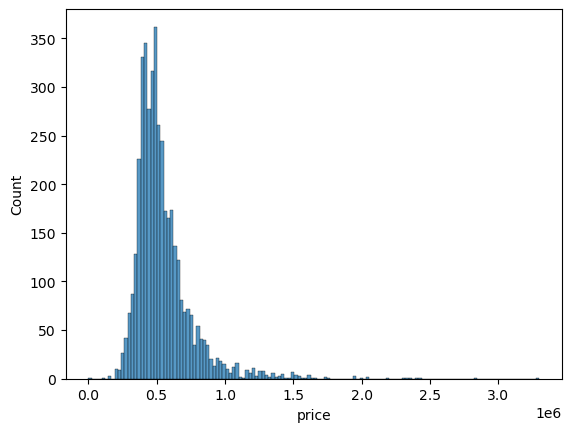

In [28]:
import seaborn as sns
sns.histplot(data=df, x="price")

transform the data

<Axes: xlabel='log_price', ylabel='Count'>

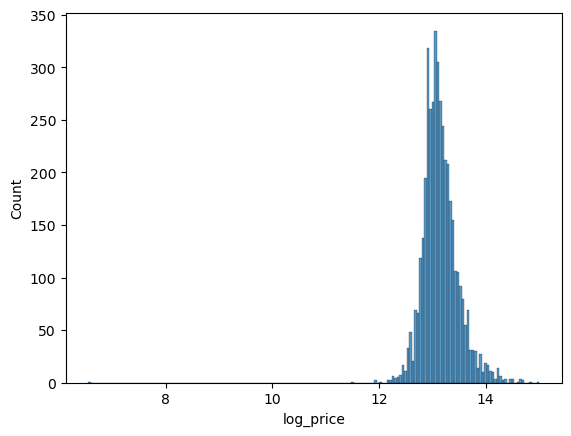

In [29]:
import numpy as np
df["log_price"] = np.log(df["price"])

sns.histplot(data=df, x="log_price")

distribution for numerical predictor variables

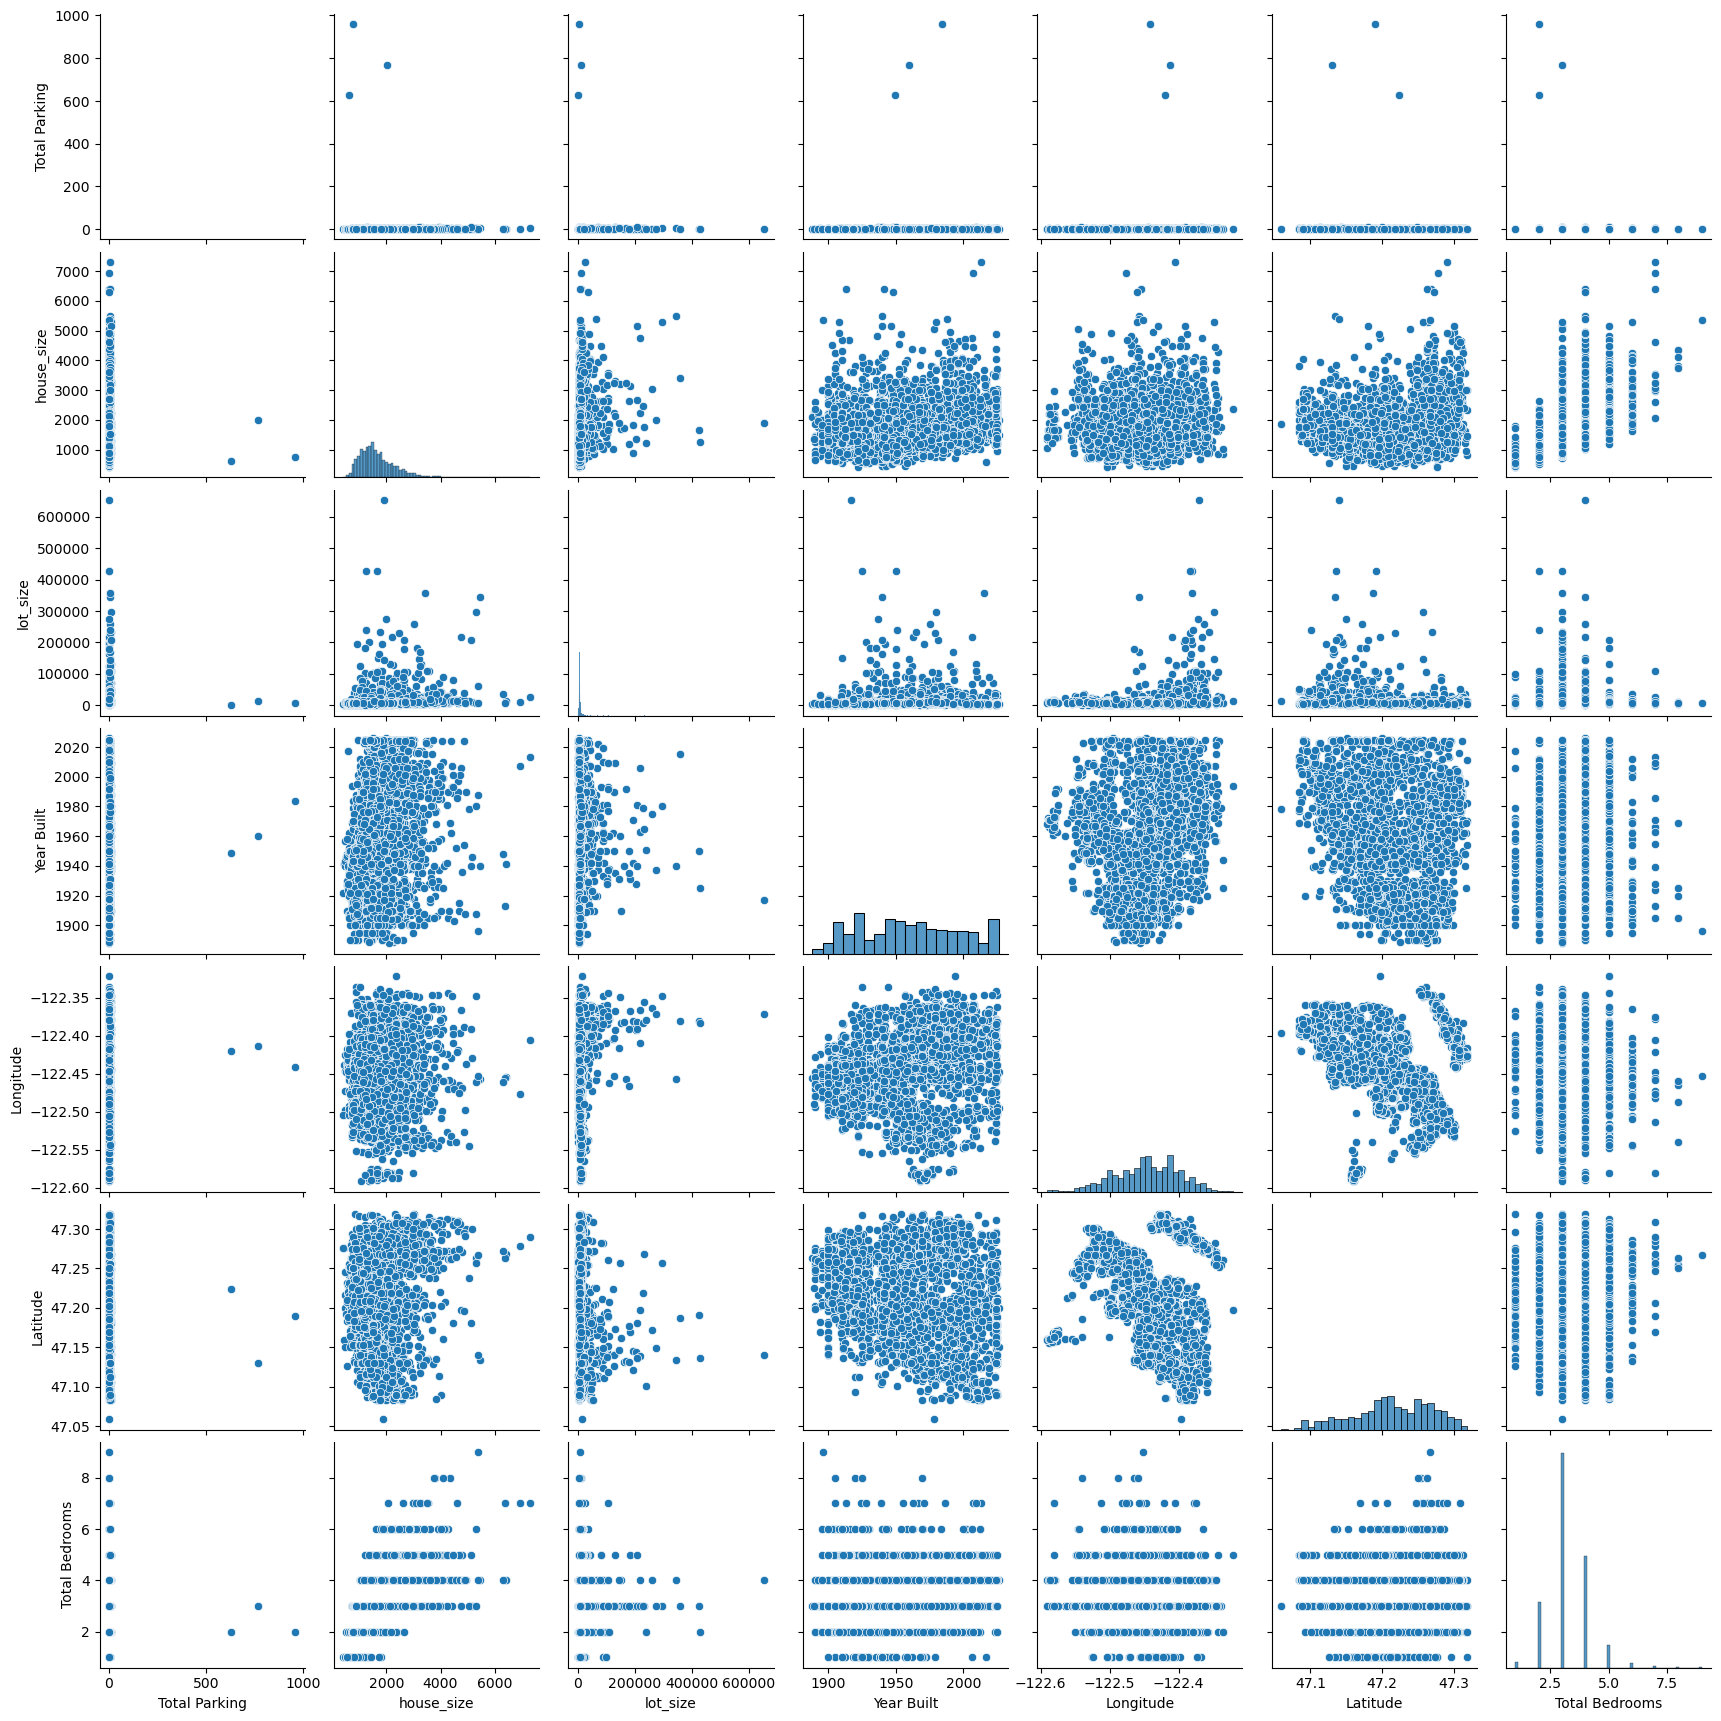

In [30]:
sns.pairplot(df, vars=[
    "Total Parking", 
    "house_size", 
    "lot_size",
    "Year Built",
    "Longitude", 
    "Latitude",
    "Total Bedrooms"
    ])

In [31]:
df.describe()

,Fireplace Y/N,Total Parking,Air Conditioning Y/N,Heating Y/N,Waterfront Y/N,Senior Community Y/N,Virtual Tour,Carport Y/N,house_size,lot_size,Year Built,Total Baths,Longitude,Latitude,Total Bedrooms,View Y/N,price,log_price
count,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4242.00000,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4242.000000,4.242000e+03,4242.000000
mean,0.556577,2.116926,0.477605,0.992692,0.006365,0.00330,0.330504,0.094767,1695.938472,10723.954455,1959.949081,2.116455,-122.446706,47.213643,3.236917,1.470061,5.475072e+05,13.152424
std,0.496847,21.181557,0.499557,0.085183,0.079536,0.05736,0.470450,0.292927,724.376525,23452.523271,36.438476,0.880568,0.045602,0.054451,0.891536,0.797411,2.226446e+05,0.342828
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,408.000000,0.000000,1888.000000,1.000000,-122.591346,47.058851,1.000000,0.000000,7.000000e+02,6.551080
25%,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1196.000000,5227.200000,1926.000000,1.000000,-122.477516,47.179669,3.000000,1.000000,4.161500e+05,12.938801
50%,1.000000,2.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1539.500000,6534.000000,1959.000000,2.000000,-122.444997,47.214531,3.000000,2.000000,4.990000e+05,13.120361
75%,1.000000,2.000000,1.000000,1.000000,0.000000,0.00000,1.000000,0.000000,2040.750000,9147.600000,1989.000000,3.000000,-122.412805,47.257417,4.000000,2.000000,6.100000e+05,13.321214
max,1.000000,960.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,7300.000000,653400.000000,2026.000000,7.000000,-122.321369,47.318861,9.000000,2.000000,3.300000e+06,15.009433


<Axes: xlabel='Property Condition', ylabel='count'>

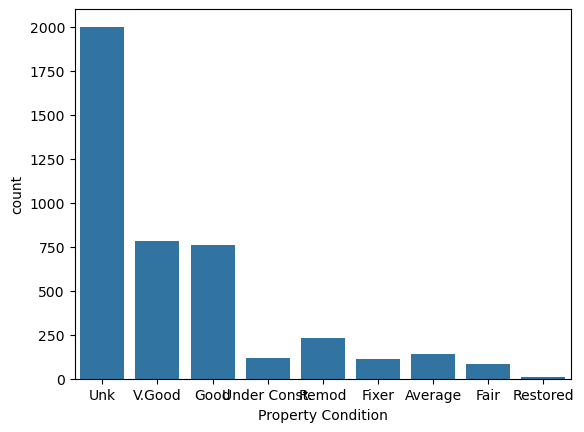

In [32]:
sns.countplot(data=df, x="Property Condition")


In [33]:
df["High School District"].unique()

array(['Tacoma', 'Franklin Pierce', 'Bethel', 'Arlington', 'Puyallup',
       'Clover Park', 'Steilacoom Historica', 'Fife', 'Marysville',
       'University Place', 'Lakewood', 'Federal Way', 'Tahoma'],
      dtype=object)

standardized values of high school district predictor variable

In [34]:
df["High School District"] = df["High School District"].map({
    "Tacoma": "TAC",
    "Franklin Pierce": "FP",
    "Bethel": "BTH",
    "Arlington": "ARL",
    "Puyallup": "PUY",
    "Clover Park": "CP",
    "Steilacoom Historica": "STH",
    "Fife": "FIF",
    "Marysville": "MARY",
    "University Place": "UP",
    "Lakewood": "LKWD",
    "Federal Way": "FW",
    "Tahoma": "TAH"
}
    
)

<Axes: xlabel='High School District', ylabel='count'>

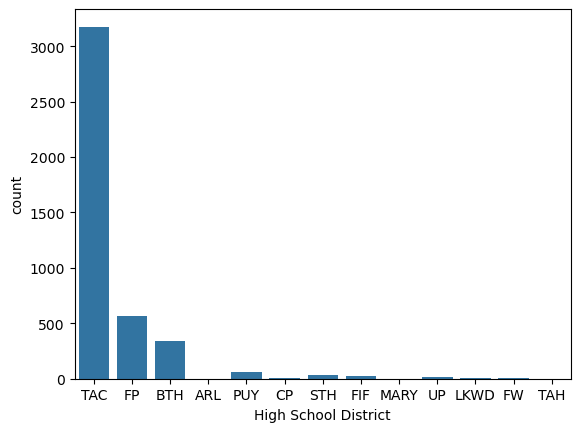

In [35]:
sns.countplot(data=df, x="High School District")

<Axes: xlabel='Structure Type', ylabel='count'>

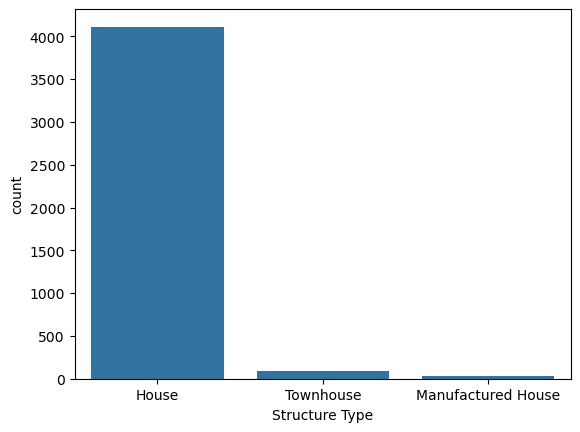

In [36]:
sns.countplot(data=df, x="Structure Type")

## Relationship between variables 

checking for multicollinearity between numeric variables

The Total Bedrooms and housing size shows is strongly positive correlated, meaning bigger house size is associated with more bedrooms. This may indicate multicollinearity between the two variables since both show similar information about the size of the house.

<Axes: >

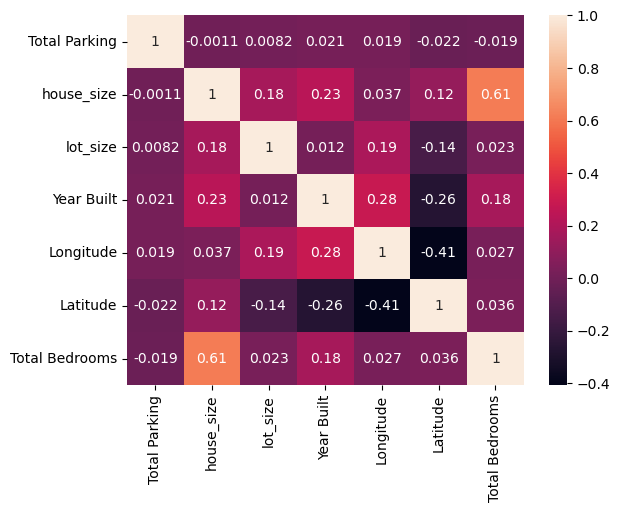

In [37]:
correla = df[[  "Total Parking", 
    "house_size", 
    "lot_size",
    "Year Built",
    "Longitude", 
    "Latitude",
    "Total Bedrooms"]].corr()
sns.heatmap(correla, annot=True)

Lot size is the one with the most right skewed distribution, hence transformating to normal

<Axes: xlabel='lot_size', ylabel='Count'>

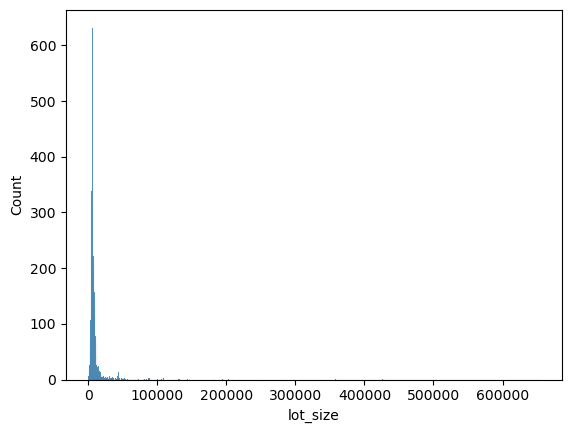

In [38]:
sns.histplot(data=df, x="lot_size")

<Axes: xlabel='log_lot_size', ylabel='Count'>

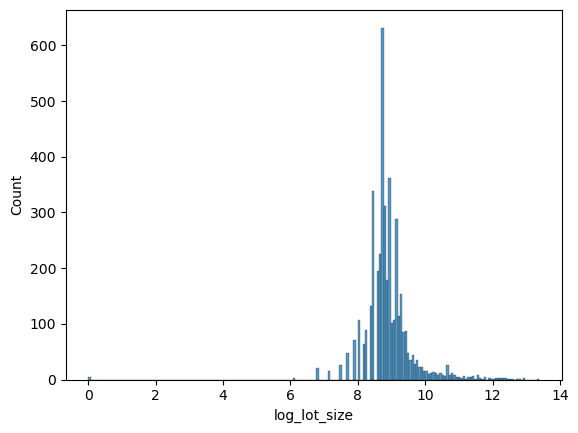

In [39]:
df["log_lot_size"] = np.log(df["lot_size"]+1)
sns.histplot(data=df, x="log_lot_size")

House size had the highest correlation with the response variable, followed by total baths. This suggests that larger homes and homes with more bathrooms tend to have higher house prices. Total Bedrooms also showed a moderate positive relationship with the response variable.

<Axes: >

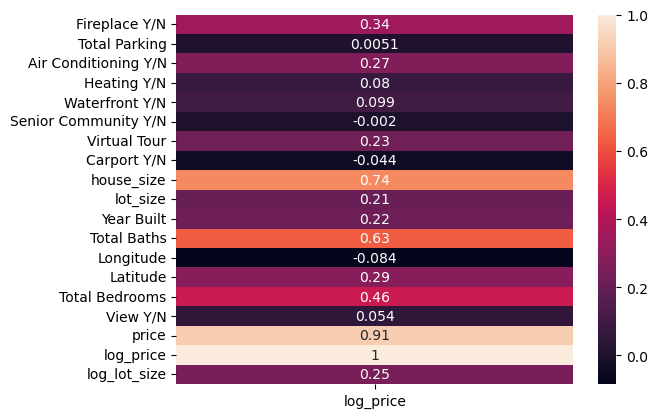

In [40]:
sns.heatmap(df.corr(numeric_only=True)[["log_price"]], annot=True)

## Feature Engineering

The scatterplot does not show a very strong linear relationship between house_age and log_price. Both newer and older homes appear across a wide range of prices, suggesting that house age alone may not be a strong predictor of house price.

<Axes: xlabel='log_price', ylabel='house_age'>

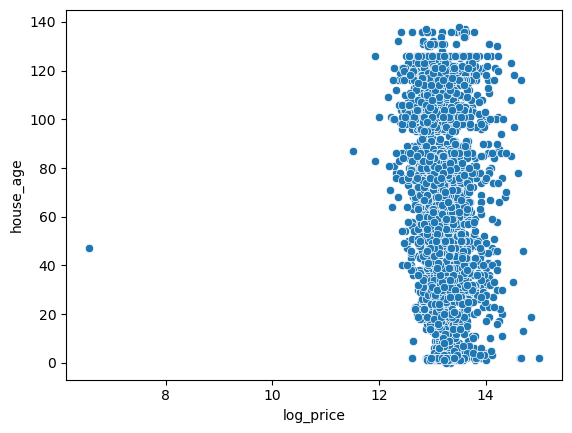

In [41]:
df["house_age"] = 2026 - df["Year Built"]

sns.scatterplot(data=df, x="log_price", y="house_age")

# PART 3: MODELING

## Model fitting

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4242 entries, 0 to 4508
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fireplace Y/N         4242 non-null   int64  
 1   Structure Type        4242 non-null   object 
 2   Total Parking         4242 non-null   float64
 3   New Construction      4242 non-null   object 
 4   Air Conditioning Y/N  4242 non-null   int64  
 5   Heating Y/N           4242 non-null   int64  
 6   High School District  4242 non-null   object 
 7   Waterfront Y/N        4242 non-null   int64  
 8   Senior Community Y/N  4242 non-null   int64  
 9   Virtual Tour          4242 non-null   int64  
 10  Carport Y/N           4242 non-null   int64  
 11  house_size            4242 non-null   float64
 12  lot_size              4242 non-null   float64
 13  Year Built            4242 non-null   int64  
 14  Total Baths           4242 non-null   int64  
 15  Longitude             4242

Single Linear Regression

In [331]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

x = df[["house_size"]]
y = df["log_price"]

x_train_slr, x_test_slr, y_train_slr, y_test_slr = train_test_split(
    x, y, test_size=0.2
)

slr_model = LinearRegression()
slr_model.fit(x_train, y_train)

slr_pred = slr_model.predict(x_test)

print("RMSE:", root_mean_squared_error(y_test, slr_pred))
print("R2:", r2_score(y_test, slr_pred))

RMSE: 0.1920183838256084
R2: 0.6073463224737373


#### Multiple Linear Regression

In [332]:
y = df["log_price"]
x = df.drop(columns=["log_price", "price", "lot_size"])

x = pd.get_dummies(x, drop_first=True, dtype="int")

x_train_mlr, x_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    x, y, test_size=0.2, random_state=42
)

full_model = LinearRegression()
full_model.fit(x_train_mlr, y_train_mlr)

full_model_pred = full_model.predict(x_test_mlr)

print("RMSE:", root_mean_squared_error(y_test_mlr, full_model_pred))
print("R2:", r2_score(y_test_mlr, full_model_pred))

RMSE: 0.14932888978988582
R2: 0.7625283762271441


#### Lasso Regression

In [333]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_mlr)
x_test_scaled = scaler.transform(x_test_mlr)

# Lasso with cross-validation
lasso_model = LassoCV(cv=10, random_state=42)

lasso_model.fit(x_train_scaled, y_train_mlr)

lasso_pred = lasso_model.predict(x_test_scaled)

print("Selected alpha:", lasso_model.alpha_)
print("RMSE:", root_mean_squared_error(y_test_mlr, lasso_pred))
print("R2:", r2_score(y_test_mlr, lasso_pred))

Selected alpha: 0.0012728532384650812
RMSE: 0.14918481411975384
R2: 0.7629863904565608


#### I chose LASSO regression model
The Lasso Regression model was selected as the final model because it achieved the lowest RMSE and highest R2 among the models evaluated. While the performance improvement over Multiple Linear Regression was small,

## Model Evaluation and Checking


Text(0, 0.5, 'Residue')

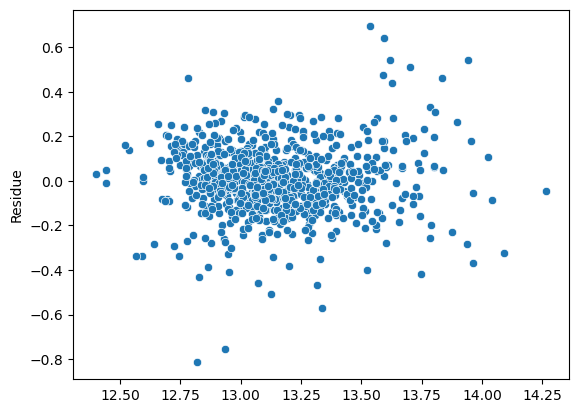

In [334]:
residuals = y_test_mlr - lasso_pred
sns.scatterplot(x=lasso_pred, y=residuals).set_ylabel("Residue")

The residual plot shows that the residuals are randomly scattered around zero with no obvious curved pattern. This suggests that the linearity assumption is reasonably satisfied. Although a few observations have relatively large residuals, there does not appear to be a strong systematic pattern indicating a major violation of linearity. The model appears to provide an adequate fit for the data.

#### observations for which the model predicted poorly

In [335]:
largest_errors = pd.DataFrame({
    "Actual": y_test_mlr,
    "Predicted": lasso_pred,
    "Residual": residuals
})

largest_errors["AbsResidual"] = abs(largest_errors["Residual"])

largest_errors.sort_values(
    by="AbsResidual",
    ascending=False
).head(10)

,Actual,Predicted,Residual,AbsResidual
2894,12.004568,12.819298,-0.814730,0.814730
2463,12.180755,12.933629,-0.752874,0.752874
3757,14.227620,13.534549,0.693071,0.693071
1198,14.237505,13.594251,0.643254,0.643254
2434,12.765688,13.335576,-0.569888,0.569888
3129,14.160518,13.618146,0.542372,0.542372
4508,14.483340,13.942812,0.540528,0.540528
561,14.210925,13.699732,0.511194,0.511194
3644,12.618182,13.127114,-0.508931,0.508931
1122,14.066269,13.591146,0.475124,0.475124


In [336]:
df.loc[[2894,2463,3757,1198,2434,3129,4508,561,3644,1122]]

,Fireplace Y/N,Structure Type,Total Parking,New Construction,Air Conditioning Y/N,Heating Y/N,High School District,Waterfront Y/N,Senior Community Y/N,Virtual Tour,...,Total Baths,Longitude,Latitude,Property Condition,Total Bedrooms,View Y/N,price,log_price,log_lot_size,house_age
2894,0,House,0.0,No,0,1,TAC,0,0,0,...,1,-122.452928,47.248545,Unk,2,2,163500,12.004568,7.686621,101
2463,0,House,0.0,No,1,1,TAC,0,0,0,...,1,-122.475410,47.243010,Fair,4,0,195000,12.180755,8.967224,81
3757,1,House,2.0,No,0,1,TAC,0,0,1,...,2,-122.494107,47.287227,Fair,5,2,1510000,14.227620,9.883438,126
1198,1,House,1.0,No,1,1,TAC,0,0,1,...,4,-122.458280,47.265876,Average,4,1,1525000,14.237505,8.715946,101
2434,0,House,1.0,No,1,1,FP,0,0,1,...,2,-122.472807,47.234041,Unk,3,2,350000,12.765688,9.212318,64
3129,1,House,3.0,No,0,1,FP,0,0,0,...,3,-122.363363,47.171580,Unk,4,2,1412000,14.160518,12.466969,51
4508,1,House,1.0,No,1,1,TAC,0,0,1,...,3,-122.490183,47.282938,Remod,4,1,1950000,14.483340,9.947973,108
561,1,House,2.0,No,0,1,CP,1,0,1,...,3,-122.539840,47.163103,V.Good,4,1,1485000,14.210925,9.254874,58
3644,0,House,2.0,No,0,0,TAC,0,0,0,...,2,-122.542930,47.254021,Unk,3,0,302000,12.618182,9.167871,51
1122,1,House,2.0,No,1,1,TAC,1,0,1,...,2,-122.434588,47.307696,V.Good,2,2,1285000,14.066269,9.444099,79


One of the houses with the largest residuals had a sale price of only $700, even though it had features similar to a normal house, such as 1,788 square feet, two bathrooms, parking, and a fireplace. This may be a data entry error or an unusual sale. Because of this, the model predicted the house price poorly. The houses with the largest residuals appear to be unusual properties that do not follow the typical pricing patterns in the dataset. To improve the model, these outliers could be investigated further or removed if they are found to be incorrect data.

## Model Interpretation


In [344]:
pd.DataFrame({
    "Variable": x_train_mlr.columns,
    "Coefficient": lasso_model.coef_
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Variable,Coefficient
8,house_size,0.136300
12,Latitude,0.124528
10,Total Baths,0.069048
15,log_lot_size,0.053311
33,Property Condition_Fixer,-0.042726
29,High School District_TAC,-0.035461
19,New Construction_Yes,0.029020
6,Virtual Tour,0.028280
11,Longitude,-0.027237
39,Property Condition_V.Good,0.026958


In [338]:
print("Slope:", full_model.intercept_)

Slope: -182.33476887723594


log_price = 0.078987 * (log_lot_size) - 184.6048

This means when the log of lot size is 0, the house price will be -184.6048. For one unit increase in the log of lot size, there will be 0.078987 increase in house price.

log_price = 0.102959 * (Property Condition_v.Good) - 184.6048

Holding all other variables constant, houses with a property condition of "Very Good" are predicted to have a log house price that is 0.102959 higher than houses in the reference property condition category.

## Updating the Model


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
import joblib

features = [
    "house_size",
    "Latitude",
    "Total Baths",
    "log_lot_size",
    "New Construction",
    "Air Conditioning Y/N",
    "Fireplace Y/N",
    "Waterfront Y/N",
    "Total Bedrooms",
    "Property Condition"
]

y = df["log_price"]
x = df[features]

# Convert categorical variables
x = pd.get_dummies(x, drop_first=True, dtype=int)

# Train/test split
x_train_mlr, x_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Scale the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_mlr)
x_test_scaled = scaler.transform(x_test_mlr)

# Lasso with cross-validation
lasso_model = LassoCV(cv=10, random_state=42)
lasso_model.fit(x_train_scaled, y_train_mlr)

lasso_pred = lasso_model.predict(x_test_scaled)

print("Selected alpha:", lasso_model.alpha_)
print("RMSE:", root_mean_squared_error(y_test_mlr, lasso_pred))
print("R2:", r2_score(y_test_mlr, lasso_pred))

Selected alpha: 0.00025574587341458397
RMSE: 0.15846608637240822
R2: 0.732578257734187


# PART 4: DEPLOYMENT

In [43]:
joblib.dump(lasso_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(x_train_mlr.columns.tolist(), "columns.pkl")

['columns.pkl']